# Case 3: Minimize CVaR with simplified UCITS constraints

## Data load

In [85]:
import numpy as np
import pandas as pd
import cvxpy as cp
import tensorflow as tf

import data_management as dm
from portfolios import Portfolio, Portfolio_Collection
from models import MPOModel
import risk_measures as rm
from utils import (
    mask_greater_than,
    sparsemax,
)

import warnings

warnings.filterwarnings("ignore")
tf.keras.backend.set_floatx("float32")

### Index and components

In [86]:
data, data_idx = dm.DataManagement.get_data(
    asset_price_path="../data/data_comp_SP500.csv",
    idx_price_path="../data/data_idx_SP500.csv",
)

### Train/Test split

In [87]:
# Desired dates.
ds_start_date = "2010-07-15"
ds_end_date = "2024-10-18"
train_start_date = "2019-12-31"
train_end_date = "2020-12-31"
test_start_date = "2021-01-01"
test_end_date = "2021-06-30"

# Sync dataframes
data, data_idx = dm.DataManagement.sync_dataframes(data, data_idx)
data_log_ret = dm.DataManagement.convert_prices_to_log_returns(data)

# Compute logarithmic returns.
data_idx_log_ret = dm.DataManagement.convert_prices_to_log_returns(data_idx)

# Filter dates.
data_log_ret = data_log_ret.loc[ds_start_date:ds_end_date, :]
data_idx_log_ret = data_idx_log_ret.loc[ds_start_date:ds_end_date, :]

# Train and test datasets.
X_train, y_train, X_test, y_test = dm.DataManagement.train_test_split_by_date(
    X=data_log_ret,
    y=data_idx_log_ret,
    train_start_date=train_start_date,
    train_end_date=train_end_date,
    test_start_date=test_start_date,
    test_end_date=test_end_date,
    train_freq="D",
)

In [88]:
risk_free_return = np.float32(0.08 / 252)
# risk_free_return = 0.0

## Portfolio optimization using gradient descent

In [89]:
def custom_loss_function(l_cvar=0.0, l_010=0.0, l_005040=0.0):
    def loss_function(
        assets_rets,  # Assets returns
        w,  # Portfolio weights
        idx=None,  # Index returns
    ):
        # We want the lambdas to be positive.
        lambda_cvar = tf.nn.relu(l_cvar)
        lambda_010 = tf.nn.relu(l_010)
        lambda_005040 = tf.nn.relu(l_005040)

        # Portfolio returns.
        p_rets = tf.matmul(assets_rets, w)

        ###############
        # CVaR
        ###############
        # Calculate CVaR at 95%.
        # This function gives the result in positive.
        cvar = rm.RiskMeasures.CVaR_tf(x=p_rets, alpha=0.05)

        ###############
        # UCITS
        ###############

        ###############
        # < 10% WEIGHT
        ###############
        # Penalty term for weight constraints.
        # Penalizes weights greater than 0.10
        penalty_010 = tf.reduce_sum(tf.nn.relu(w - 0.10))

        ###############
        # > 5% WEIGHT => SUM < 40%
        ###############
        # Penalty term for weight constraints.
        # Penalizes sum of weights exceeding 0.40
        mask = mask_greater_than(w, 0.05)
        weights_over_005 = tf.multiply(w, mask)
        penalty_005040 = tf.nn.relu(tf.reduce_sum(weights_over_005) - 0.40)

        # Update the loss.
        loss = lambda_cvar * cvar + lambda_010 * penalty_010 + lambda_005040 * penalty_005040

        return {
            "loss": loss,  # Only for training, without converting to numpy.
            "weights": w.numpy(),
            "metrics": {
                "loss": loss.numpy(),
                "loss_cvar": (lambda_cvar * cvar).numpy(),
                "loss_010": (lambda_010 * penalty_010).numpy(),
                "loss_005040": (lambda_005040 * penalty_005040).numpy(),
                "theoretical_loss_010": penalty_010.numpy(),
                "theoretical_loss_005040": penalty_005040.numpy(),
            },
        }

    return loss_function

In [90]:
def custom_get_best_weights():
    def get_best_weights(history: list) -> np.ndarray:
        weights = pd.DataFrame([h["weights"].squeeze() for h in history])
        metrics = pd.DataFrame([h["metrics"] for h in history])
        idx_min_loss = metrics["loss"].idxmin()
        selected_weights = weights.loc[idx_min_loss].to_numpy()
        return selected_weights.squeeze()

    return get_best_weights

In [91]:
def custom_weights_function():
    return sparsemax

In [92]:
num_assets = X_train.shape[1]
loss_function = custom_loss_function(l_cvar=1.0, l_010=1.0, l_005040=1.0)
weights_function = custom_weights_function()
get_best_weights_function = custom_get_best_weights()
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

mpo = MPOModel(
    num_assets=num_assets,
    loss_function=loss_function,
    weights_function=weights_function,
    get_best_weights_function=get_best_weights_function,
    optimizer=optimizer,
    random_weight_init=False,
)

In [93]:
history = mpo.fit(x=X_train, idx=y_train, epochs=2000)

100%|██████████| 2000/2000 [01:22<00:00, 24.28it/s]


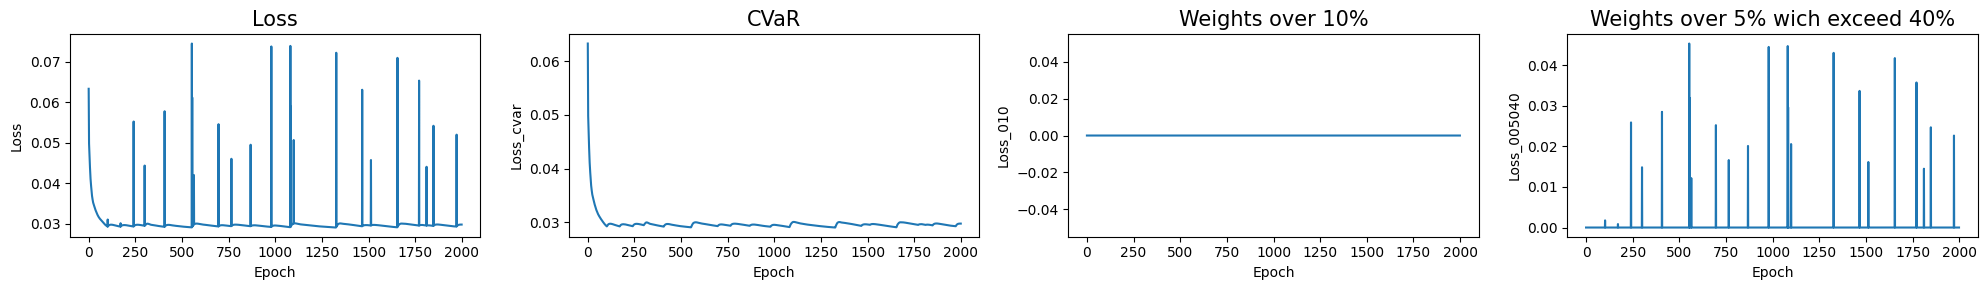

In [94]:
mpo.plot_all_training_metrics(
    save_as="../results/Case_03/MinCVaR_UCITS_gd_optimizer_training_metrics.png",
    titles={
        "loss": "Loss",
        "loss_cvar": "CVaR",
        "loss_010": "Weights over 10%",
        "loss_005040": "Weights over 5% wich exceed 40%",
    },
)

In [95]:
gd_portfolio_name = "Case 3 - GD"
gd_portfolio = Portfolio(
    name=gd_portfolio_name,
    asset_weights=mpo.get_best_weights(),
    asset_names=X_train.columns,
)

In [100]:
mpo.history[-1]

{'loss': <tf.Tensor: shape=(), dtype=float32, numpy=0.029762644>,
 'weights': array([[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.04812968],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],

Sum of weights > 5%: 0.39979350566864014
Number of assets in portfolio: 23


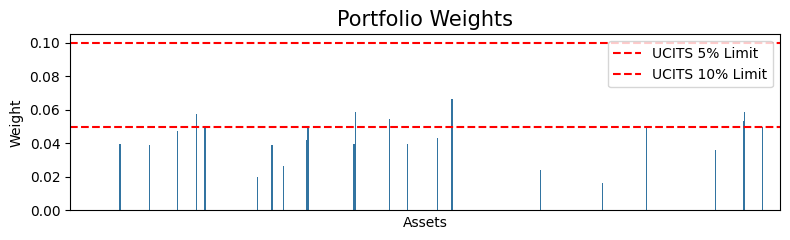

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & A & AAPL & ABT & ACGL & ACN & ADBE & ADI & ADM & ADP & ADSK & AEE & AEP & AES & AFL & AIG & AIZ & AJG & AKAM & ALB & ALGN & ALL & AMAT & AMD & AME & AMGN & AMP & AMT & AMZN & ANSS & AON & AOS & APA & APD & APH & ARE & ATO & AVB & AVGO & AVY & AWK & AXON & AXP & AZO & BA & BAC & BALL & BAX & BBY & BDX & BEN & BG & BIIB & BK & BKNG & BKR & BLDR & BLK & BMY & BR & BRO & BSX & BWA & BX & BXP & C & CAG & CAH & CAT & CB & CBOE & CBRE & CCI & CCL & CDNS & CE & CF & CHD & CHRW & CHTR & CI & CINF & CL & CLX & CMCSA & CME & CMG & CMI & CMS

In [96]:
gd_portfolio.plot_weights(
    plot_ucits_limits=True,
    skip_zero_weights=False,
    save_as="../results/Case_03/MinCVaR_UCITS_gd_optimizer_portfolio_weights.png",
    figsize=(8, 2.5),
)

Sum of weights > 5%: 0.39979350566864014
Number of assets in portfolio: 23


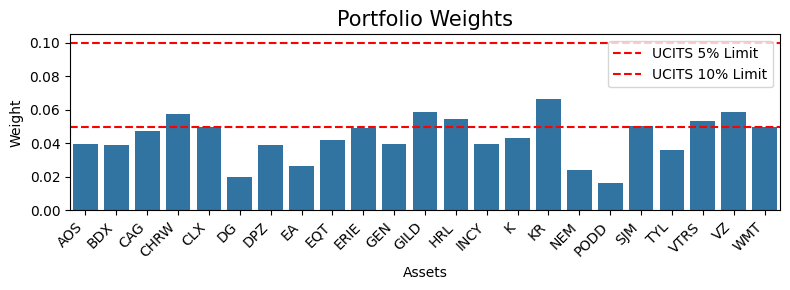

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & AOS & BDX & CAG & CHRW & CLX & DG & DPZ & EA & EQT & ERIE & GEN & GILD & HRL & INCY & K & KR & NEM & PODD & SJM & TYL & VTRS & VZ & WMT \\
\midrule
Weight & 0.039855 & 0.038734 & 0.047116 & 0.057625 & 0.049687 & 0.019987 & 0.039271 & 0.026237 & 0.041741 & 0.049108 & 0.039672 & 0.058952 & 0.054397 & 0.039594 & 0.043403 & 0.066540 & 0.024005 & 0.016132 & 0.050218 & 0.035808 & 0.053264 & 0.058796 & 0.049857 \\
\bottomrule
\end{tabular}



In [97]:
gd_portfolio.plot_weights(
    plot_ucits_limits=True,
    skip_zero_weights=True,
    save_as="../results/Case_03/MinCVaR_UCITS_gd_optimizer_portfolio_weights_no_zeros.png",
    figsize=(8, 3),
)

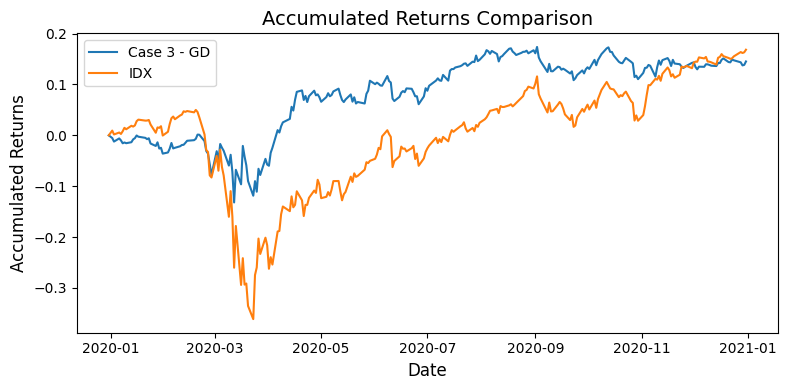

                  Std    Sharpe  TrackingError       VaR      CVaR  \
Case 3 - GD  0.013704  0.019866       0.013078  0.020722  0.029034   
IDX          0.021113  0.016771       0.000000  0.033728  0.056878   

             WeightsOver10pct  WeightsOver5pct  
Case 3 - GD               0.0         0.399794  
IDX                       NaN              NaN  


In [98]:
# Allows us to store and compare different portfolios.
portfolios = Portfolio_Collection(portfolio_names=[], portfolio_weights=[], asset_names=X_train.columns)

portfolios.replace_or_add_portfolio(name=gd_portfolio.name, new_portfolio=gd_portfolio)

portfolios.plot_cumulative_returns(
    asset_returns=X_train,
    idx_returns=y_train,
    portfolio_names=[
        gd_portfolio.name,
    ],
    plot_idx=True,
    comparable_returns=[],
    rf=risk_free_return,
    zero_start=True,
    save_as="../results/Case_03/MinCVaR_UCITS_gd_optimizer_portfolio_acum_returns_comparison.png",
    figsize=(8, 4),
)